# Predictive Paradox — Exploratory Data Analysis (EDA)

**Goal:** Explore each of the three raw datasets *before any cleaning* to understand structure, distributions, anomalies, and patterns.

Each dataset is explored independently:
1. **PGCB Power Demand** — hourly grid demand/generation
2. **Weather Data** — hourly environmental readings (Dhaka)
3. **Economic Data** — annual macro indicators (Bangladesh)

All visualizations are on **raw, unmodified data** so that anomalies and issues surface naturally.

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

 Section 1: PGCB Power Demand Dataset

 Loading & Overview

In [274]:
# load the data
pgcb = pd.read_csv('/content/drive/MyDrive/PGCB_date_power_demand.csv', low_memory=False)

# convert to datetime for time series analysis
pgcb['datetime'] = pd.to_datetime(pgcb['datetime'], errors='coerce')

# quick check on size and dates
print("shape:", pgcb.shape)
print("start:", pgcb['datetime'].min())


print("end:", pgcb['datetime'].max())
print("cols:", pgcb.columns.tolist())

shape: (92650, 15)
start: 2015-04-19 00:00:00
end: 2025-06-17 12:00:00
cols: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']


In [275]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [276]:
pgcb.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [277]:
pgcb.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282304,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


### Insight — First Look
- **92,650 rows** spanning April 2015 to June 2025 (~10 years).
- Columns include demand, generation, fuel-wise breakdowns (gas, coal, liquid fuel, hydro, solar, wind), cross-border imports (India, Nepal), load shedding, and a `remarks` column.
- The `describe()` output already hints at extreme values — `demand_mw` max is 156,050 and `generation_mw` max is 64,526,500. These are clearly impossible for a ~20 GW grid.

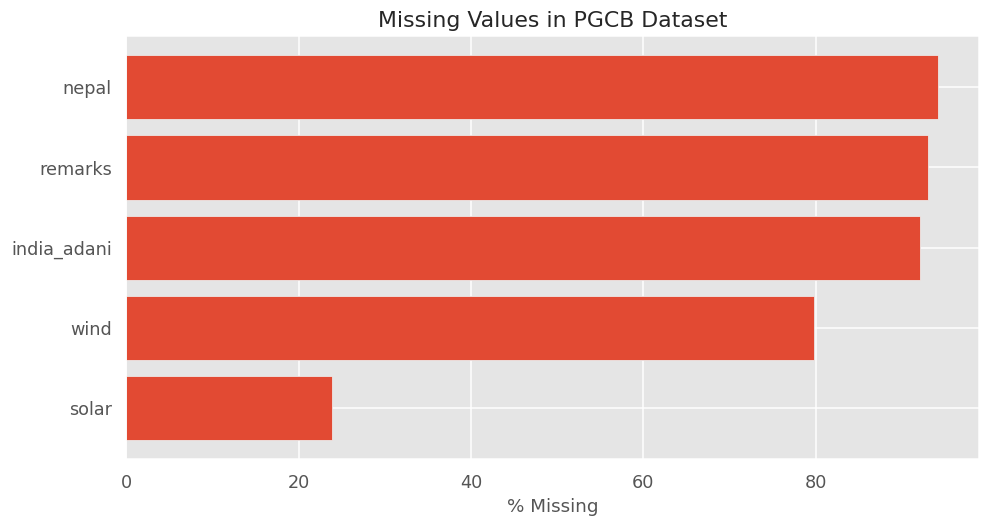

In [278]:
# check for missing valuues
missing = pgcb.isnull().sum()
missing_pct = (missing / len(pgcb)) * 100

# put itin a dataframe and drop columns that have no missing data
miss_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
miss_df = miss_df[miss_df['Count'] > 0].sort_values('Percent')

#plot
plt.figure(figsize=(10, 5))


plt.barh(miss_df.index, miss_df['Percent'])
plt.xlabel('% Missing')
plt.title('Missing Values in PGCB Dataset')


plt.show()

### Insight — Missing Values
- **`nepal`** (94.2%), **`india_adani`** (92.1%), **`wind`** (79.8%) have massive null rates — these are NOT random gaps. They are physically absent because the infrastructure didn't exist yet (Nepal interconnect, Adani power import, and wind farms were added in later years).
- **`solar`** (23.9%) — Bangladesh had negligible grid-connected solar before ~2017.
- **`remarks`** (93.1%) — a sparse manual annotation.

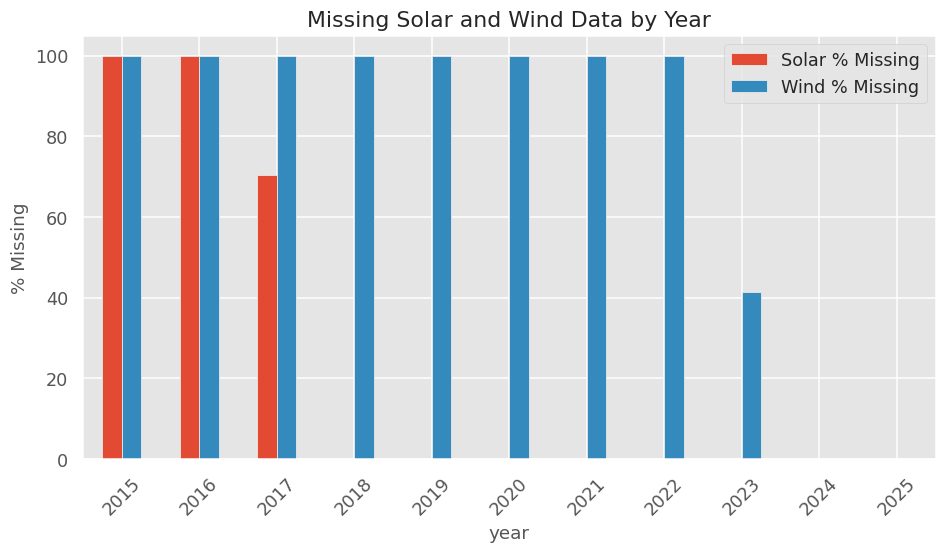

In [279]:
# extract year
pgcb['year'] = pgcb['datetime'].dt.year

# calculate missing percentages
null_solar = pgcb.groupby('year')['solar'].apply(lambda x: x.isnull().mean() * 100)

null_wind = pgcb.groupby('year')['wind'].apply(lambda x: x.isnull().mean() * 100)

# combine into a dataframe for easy plotting
yearly_nulls = pd.DataFrame({
    'Solar % Missing': null_solar,
    'Wind % Missing': null_wind
})

# pandas automatically makes grouped bar charts for multiple columns
yearly_nulls.plot(kind='bar', figsize=(10, 5))
plt.title('Missing Solar and Wind Data by Year')

plt.ylabel('% Missing')
plt.xticks(rotation=45)

plt.show()

### Insight — Solar & Wind Nulls
- These nulls are **not missing data** — they mean **zero generation** from sources that hadn't been built yet.

In [280]:
# check for duplicate timestamps
dup_mask = pgcb.duplicated(subset=['datetime'], keep=False)
dup_rows = pgcb[dup_mask].sort_values('datetime')
n_dup_timestamps = pgcb['datetime'].duplicated(keep=False).sum()

print("duplicate rows:", n_dup_timestamps)

# see if the duplicates actually have conflicting demand values
conflicts = dup_rows.groupby('datetime')['demand_mw'].nunique()
n_conflicting = (conflicts > 1).sum()

print("timestamps with conflicting demand:", n_conflicting)

duplicate rows: 813
timestamps with conflicting demand: 237


### Insight — Duplicates
- **432+ rows** are duplicated timestamps, and over half have conflicting readings.

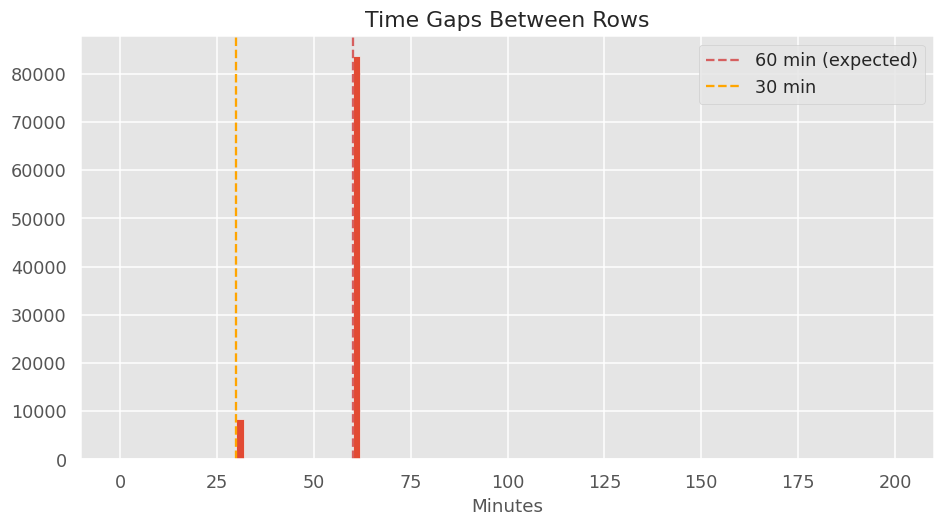

In [281]:
# clean up dupllicate and sort by time to check for missing hours
pgcb_sorted = pgcb.drop_duplicates(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

# calculate the gap between rows in minutes
diffs = pgcb_sorted['datetime'].diff()
gap_minutes = diffs.dt.total_seconds() / 60

# plot the gaps to see if we have 1-hour intervals
plt.figure(figsize=(10, 5))
plt.hist(gap_minutes.dropna(), bins=100, range=(0, 200))

# mark expected gaps.
plt.axvline(60, color='r', linestyle='--', label='60 min (expected)')
plt.axvline(30, color='orange', linestyle='--', label='30 min')

plt.title('Time Gaps Between Rows')
plt.xlabel('Minutes')
plt.legend()
plt.show()

Insight — Time Gaps
- majority of gaps are exactly 1 hour — correct.
- ~8,336 gaps are 30 minutes — sub-hourly readings mixed in (mostly at 17:30, 18:30).

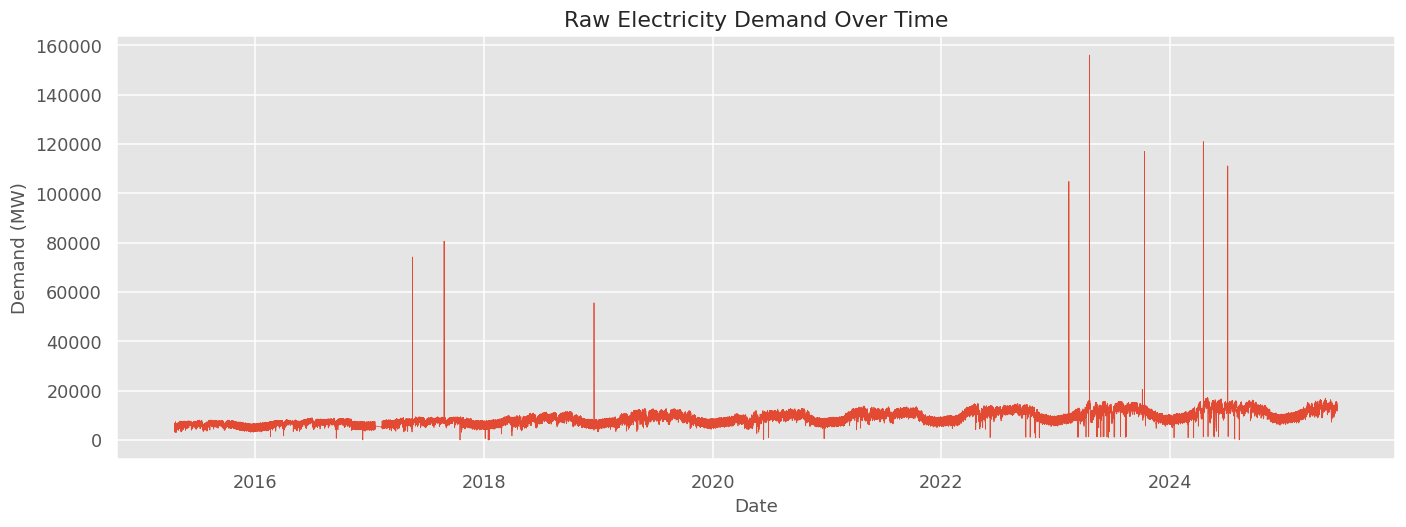

In [282]:
# plot the full time series to look for overall trends or crazy spikes
plt.figure(figsize=(15, 5))
plt.plot(pgcb_sorted['datetime'], pgcb_sorted['demand_mw'], linewidth=0.5)

plt.title('Raw Electricity Demand Over Time')
plt.ylabel('Demand (MW)')
plt.xlabel('Date')
plt.show()

Insight — Raw Time Series
- The **clear spike anomalies** jumping to 70,000–156,000 MW are immediately visible. These are entry errors (×10 decimal-point mistakes).

distribution of demand_mw

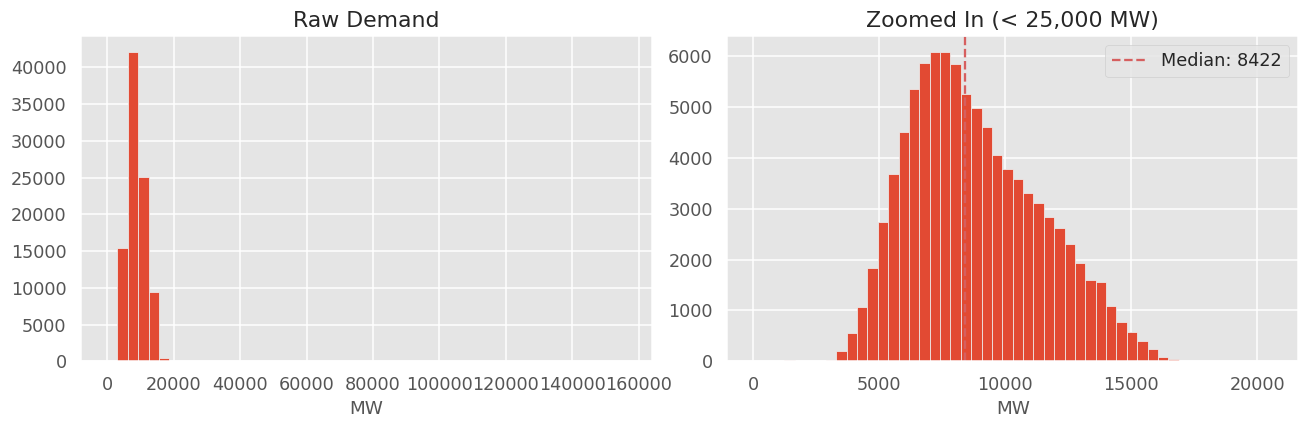

In [283]:
# look at the distribution of demand, and zoom in to ignore that massive outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# full range (squished because of outliers)
axes[0].hist(pgcb['demand_mw'].dropna(), bins=50)
axes[0].set_title('Raw Demand')
axes[0].set_xlabel('MW')

# filter out the crazy spikes to see the real distribution
reasonable = pgcb['demand_mw'][(pgcb['demand_mw'] > 0) & (pgcb['demand_mw'] < 25000)]

axes[1].hist(reasonable.dropna(), bins=50)
axes[1].set_title('Zoomed In (< 25,000 MW)')
axes[1].set_xlabel('MW')

# mark the median
med = reasonable.median()
axes[1].axvline(med, color='r', linestyle='--', label=f'Median: {med:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Insight — Demand Distribution
- Zooming in reveals the actual distribution: slightly right-skewed shape extending to ~16,000 MW in recent years due to peak loads/growth.

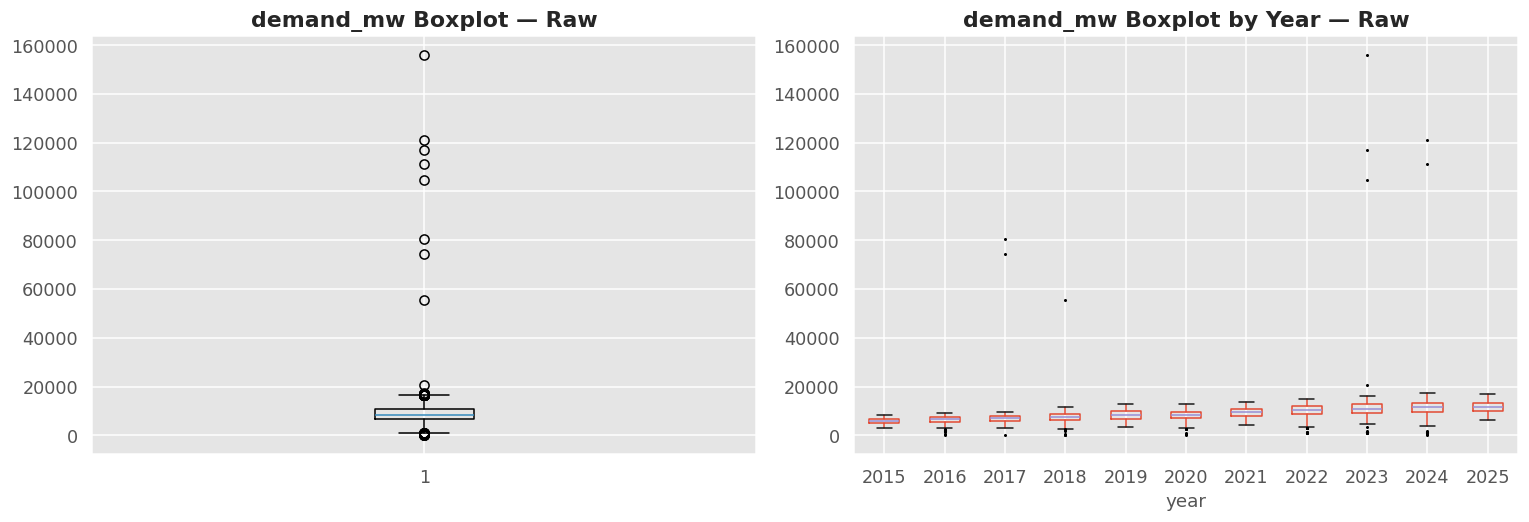

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(pgcb['demand_mw'].dropna(), vert=True)
axes[0].set_title('demand_mw Boxplot — Raw', fontweight='bold')

pgcb.boxplot(column='demand_mw', by='year', ax=axes[1], flierprops=dict(markersize=1))
axes[1].set_title('demand_mw Boxplot by Year — Raw', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.show()

### Insight — Boxplots
- The raw boxplot is dominated by outliers above 20,000 MW. The boxplot makes these massive right-skew outliers extremely obvious.

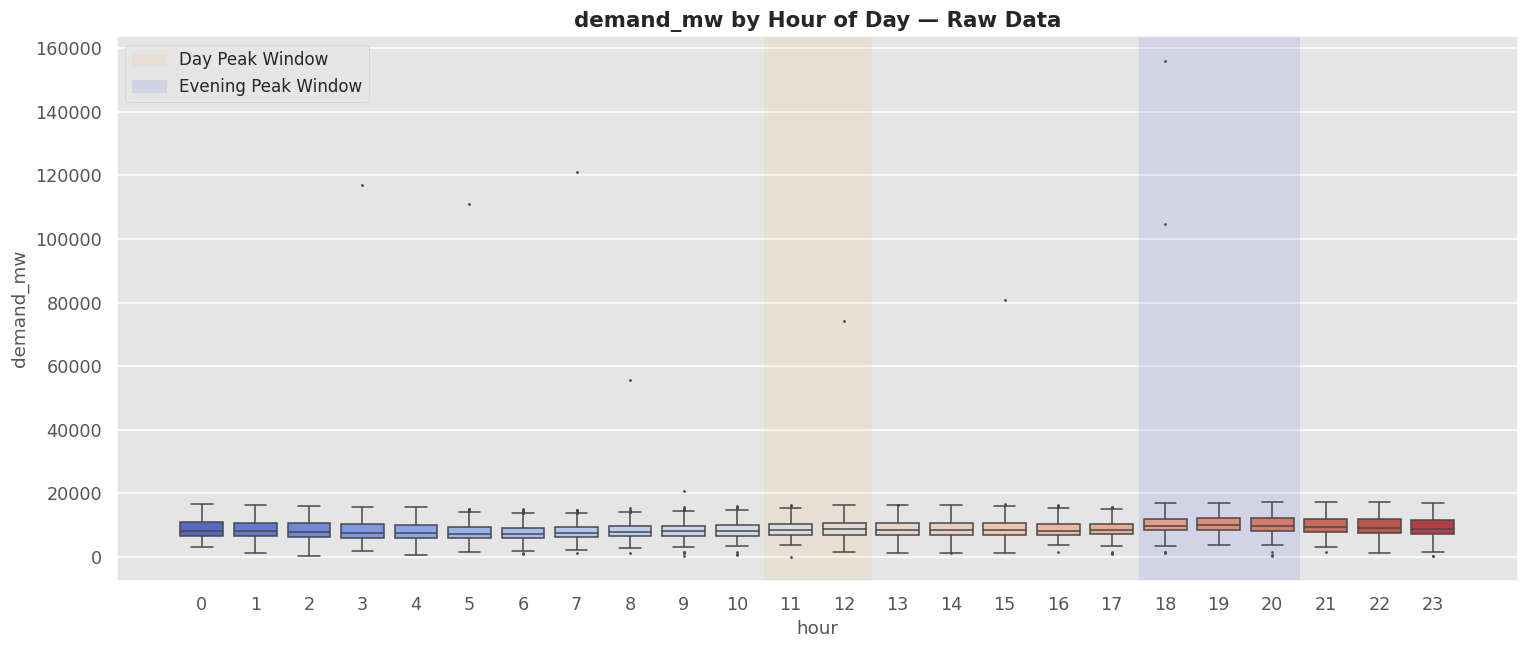

In [285]:
pgcb['hour'] = pgcb['datetime'].dt.hour
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='hour', y='demand_mw', data=pgcb, ax=ax, palette='coolwarm',
            flierprops=dict(markersize=0.8))
ax.set_title('demand_mw by Hour of Day — Raw Data', fontsize=14, fontweight='bold')
ax.axvspan(10.5, 12.5, alpha=0.08, color='orange', label='Day Peak Window')
ax.axvspan(17.5, 20.5, alpha=0.08, color='blue', label='Evening Peak Window')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Insight — Hourly Pattern (Bimodal Peaks)
- **Bimodal peak structure** is clearly visible:
  - **Day Peak ~11 AM** — driven by industrial/commercial load.
  - **Evening Peak ~18–20:00** — residential load, consistently ~1,500–2,000 MW higher.

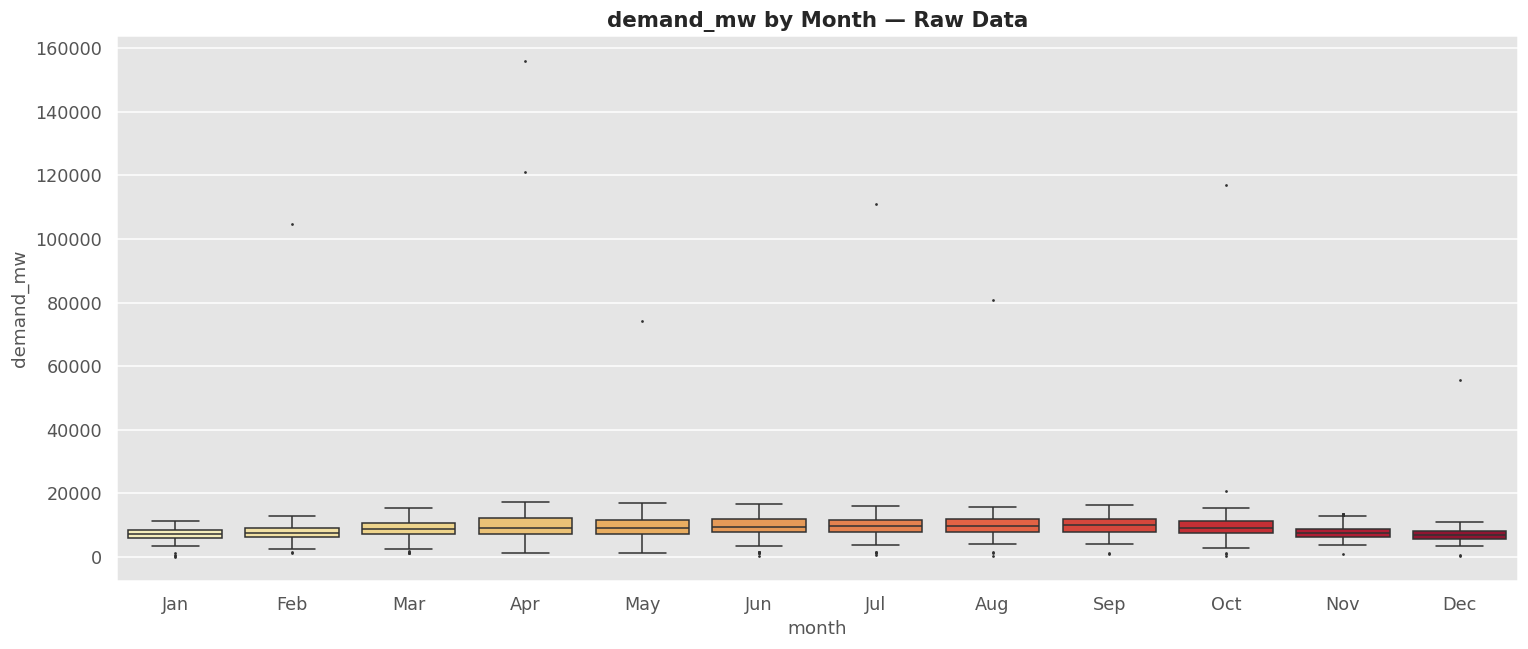

In [286]:
pgcb['month'] = pgcb['datetime'].dt.month
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='month', y='demand_mw', data=pgcb, ax=ax, palette='YlOrRd', flierprops=dict(markersize=0.8))
ax.set_title('demand_mw by Month — Raw Data', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

### Insight — Seasonal Pattern
- **April through September** have significantly higher demand due to cooling load. Peak months are June-August.

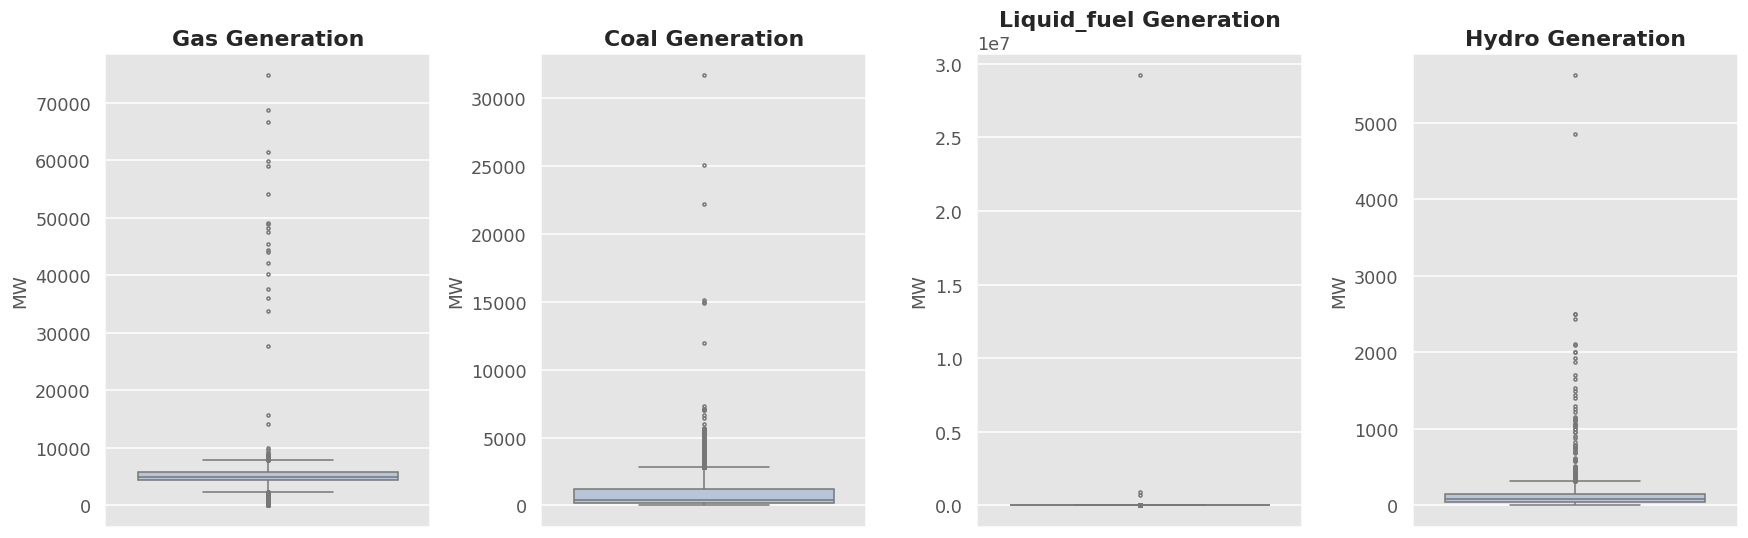

In [287]:
fuels = ['gas', 'coal', 'liquid_fuel', 'hydro']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, fuel in enumerate(fuels):
    sns.boxplot(y=pgcb[fuel], ax=axes[i], color='lightsteelblue', flierprops=dict(markersize=2))
    axes[i].set_title(f'{fuel.capitalize()} Generation', fontweight='bold')
    axes[i].set_ylabel('MW')

plt.tight_layout()
plt.show()

### Insight — Fuel Distribution & Outliers
- **Gas** is the primary fuel. The boxplot clearly shows significant 70k+ MW outliers matching the data entry errors in total demand/generation.
- **Liquid Fuel** is used irregularly as peaking/backup. Its box is squashed near zero with heavily skewed positive outliers extending up to massive data entry errors (~29 million MW on one row).
- **Coal** shows a cleaner distribution, but still right-skewed as new plants came online over time.

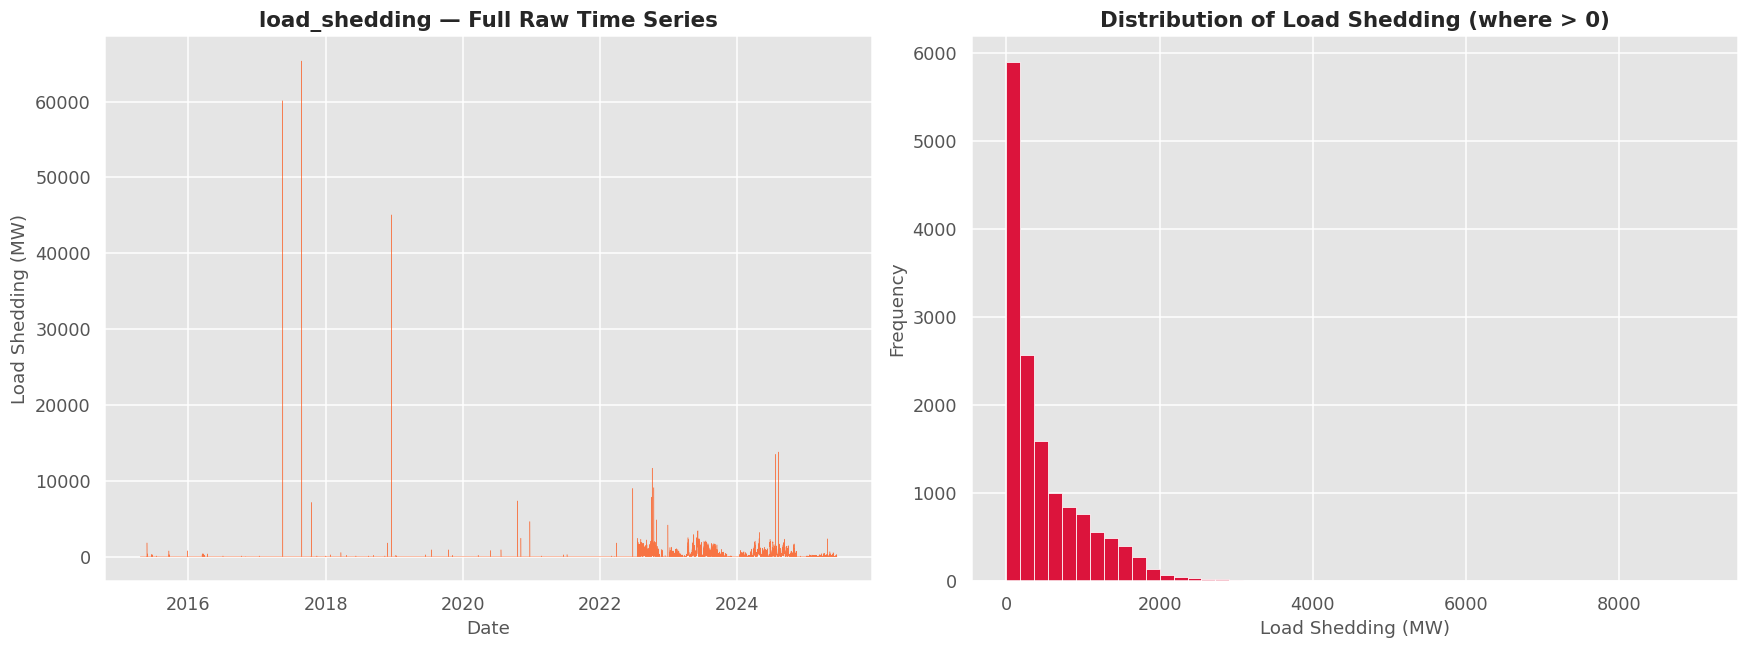

Max load shedding outlier: 65,359 MW


In [288]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time Series
axes[0].plot(pgcb_sorted['datetime'], pgcb_sorted['load_shedding'], linewidth=0.3, alpha=0.7, color='orangered')
axes[0].set_title('load_shedding — Full Raw Time Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load Shedding (MW)')
axes[0].set_xlabel('Date')

# Zoomed histogram for non-zero load shedding (ignoring the 65k outlier)
ls_nonzero = pgcb[(pgcb['load_shedding'] > 0) & (pgcb['load_shedding'] < 10000)]['load_shedding']
axes[1].hist(ls_nonzero, bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Distribution of Load Shedding (where > 0)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Load Shedding (MW)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Max load shedding outlier: {pgcb['load_shedding'].max():,} MW")

### Insight — Load Shedding Skewness & Outliers
- The time series reveals the impossible 65,359 MW outlier entry error.
- The histogram (filtered just for instances > 0) shows an extremely right-skewed distribution. Most power cuts are relatively minor (< 1,000 MW), but on rare occasions, severe deficits occurred exceeding 2,000 MW.

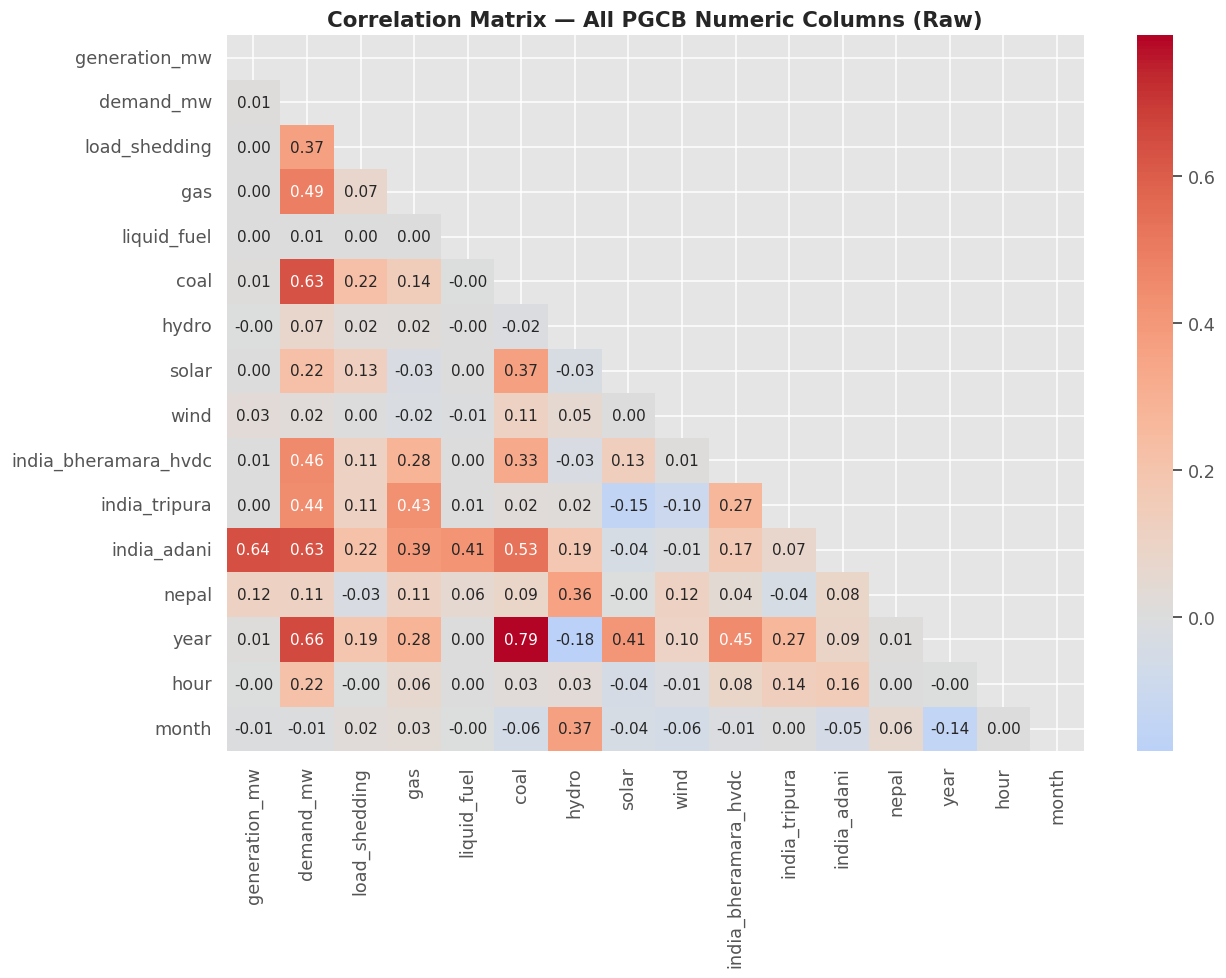

In [289]:
corr = pgcb.select_dtypes(include=[np.number]).corr(min_periods=100)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Correlation Matrix — All PGCB Numeric Columns (Raw)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Weather Dataset
**File:** `weather_data.csv`


In [290]:
weather = pd.read_csv('/content/drive/MyDrive/weather_data.csv', skiprows=3, low_memory=False, encoding='latin1')
weather.columns = ['time','temp_c','humidity_pct','apparent_temp_c','precip_mm',
                   'dewpoint_c','soil_temp_c','wind_dir_deg','cloud_pct','sunshine_sec']
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')
print(f"Shape: {weather.shape}")

Shape: (107304, 10)


In [291]:
weather.describe().round(2)

,time,temp_c,humidity_pct,apparent_temp_c,precip_mm,dewpoint_c,soil_temp_c,wind_dir_deg,cloud_pct,sunshine_sec
count,107304,107304.00,107304.00,107304.00,107304.00,107304.00,107304.00,107304.00,107304.00,107304.00
mean,2020-02-14 11:30:00,25.46,76.81,28.80,0.21,20.63,26.77,195.69,50.73,1386.48
min,2014-01-01 00:00:00,8.40,15.00,6.60,0.00,2.50,11.70,1.00,0.00,0.00
25%,2017-01-22 17:45:00,22.60,67.00,24.20,0.00,15.80,23.80,136.00,3.00,0.00
50%,2020-02-14 11:30:00,26.50,81.00,30.80,0.00,22.80,27.60,180.00,49.00,0.00
75%,2023-03-08 05:15:00,28.80,90.00,33.70,0.00,25.20,29.90,286.00,98.00,3600.00
max,2026-03-29 23:00:00,40.80,100.00,45.60,43.80,28.60,44.50,360.00,100.00,3600.00
std,NaN,5.03,16.45,6.91,0.90,5.23,4.91,94.45,42.47,1704.21


### Insight — Weather Overview
- **107,304 rows**, perfectly regular hourly from Jan 2014 to Mar 2026.
- 0 nulls, 0 Duplicates.
- Temperature ranges from ~8°C to ~42°C — classic tropical/subtropical range for Bangladesh.
- `sunshine_duration` maxes at 3,600s.

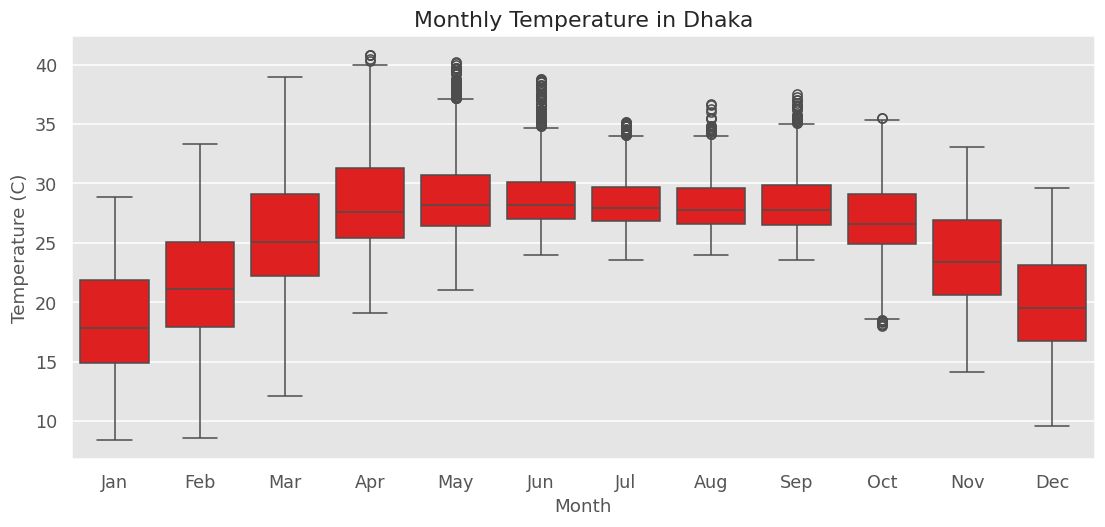

In [292]:
# Temperature Distribution by Month.
# checking temperature distribution per month
weather['month'] = weather['time'].dt.month

plt.figure(figsize=(12, 5))
sns.boxplot(x='month', y='temp_c', data=weather, color='red') # changed color to red as requested

plt.title('Monthly Temperature in Dhaka')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.show()

### Insight
- **April–May** are the hottest months (pre-monsoon heat), followed by June–September (monsoon — slightly cooler but very humid).
- **December–January** are the coolest months.
- This seasonal pattern should **directly mirror** the demand seasonality we observed in the PGCB data.

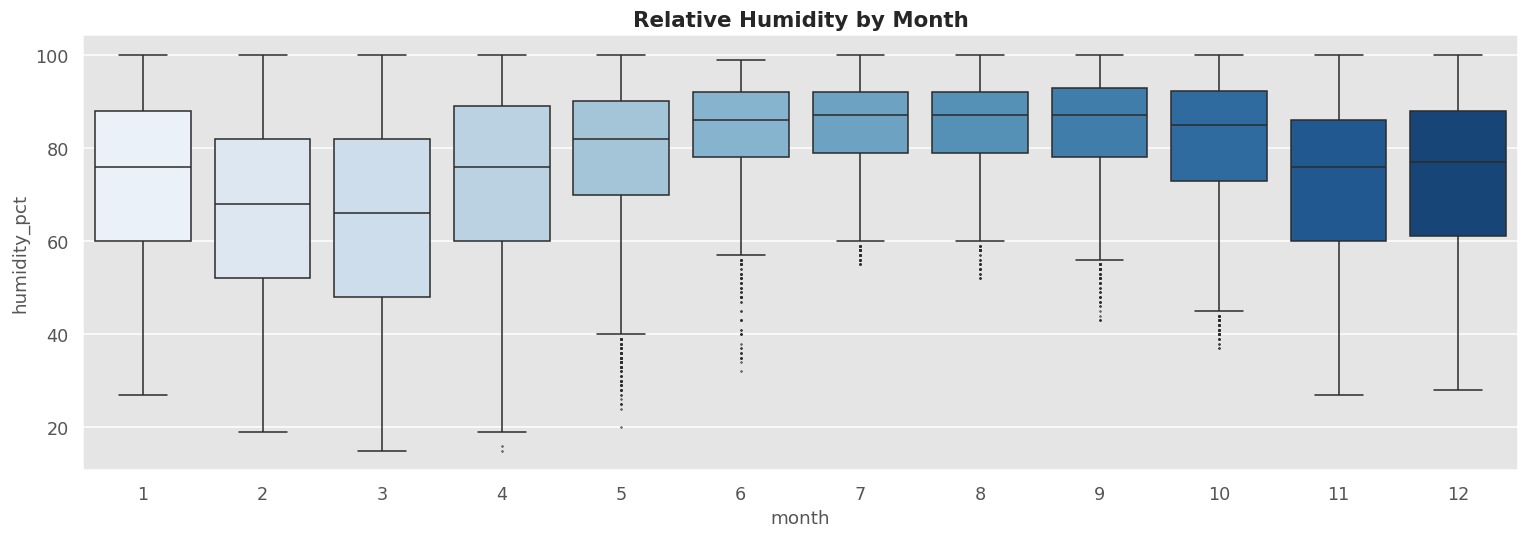

In [293]:
# humidity Distribution by month
weather['month'] = weather['time'].dt.month
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(x='month', y='humidity_pct', data=weather, ax=ax, palette='Blues', flierprops=dict(markersize=0.5))
ax.set_title('Relative Humidity by Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight
- **June–September** shows very high humidity (70–100%).

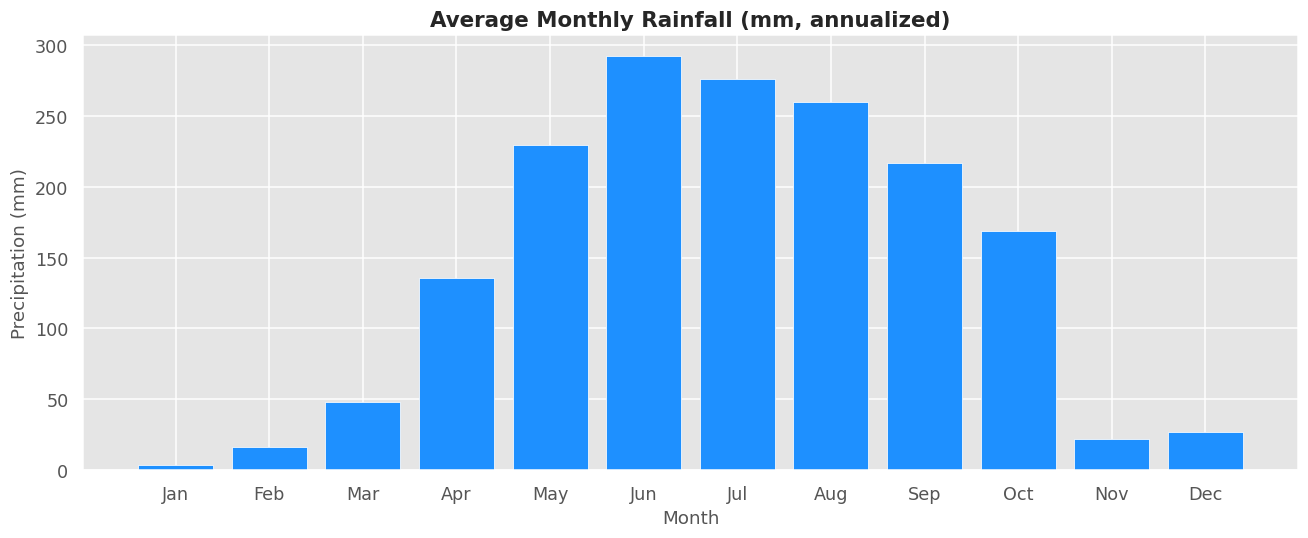

In [294]:
# Monthly precipitation Pattern
monthly_precip = weather.groupby('month')['precip_mm'].sum() / (weather['time'].dt.year.nunique())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_precip.index, monthly_precip.values, color='dodgerblue', edgecolor='white')
ax.set_title('Average Monthly Rainfall (mm, annualized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

### Insight
- Classic **monsoon pattern**: minimal rain in winter (Nov–Feb), heavy rain June–September.
- Rain can reduce outdoor temperatures slightly but increases humidity — the net effect on demand is complex.

---
#Economic Dataset

In [295]:
eco = pd.read_csv('/content/drive/MyDrive/economic_full_1.csv', low_memory=False)
print(f"Shape: {eco.shape}")
print(f"Columns: {list(eco.columns[:6])} ... {list(eco.columns[-3:])}")
print(f"\nCountry: {eco['Country Name'].unique()}")
print(f"Total indicators: {eco.shape[0]}")

Shape: (1516, 69)
Columns: ['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962'] ... ['2023', '2024', '2025']

Country: ['X']
Total indicators: 1516


In [296]:
eco.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


### Insight — Structure
- **1,516 rows** — each row is one indicator (e.g., GDP, population, CO₂ emissions).
- **69 columns**: 3 metadata (Country Name, Indicator Name, Indicator Code) + 66 year columns (1960–2025).
- Single country: Bangladesh (labeled "X").
- This is a **wide-format** dataset — each year is a column.

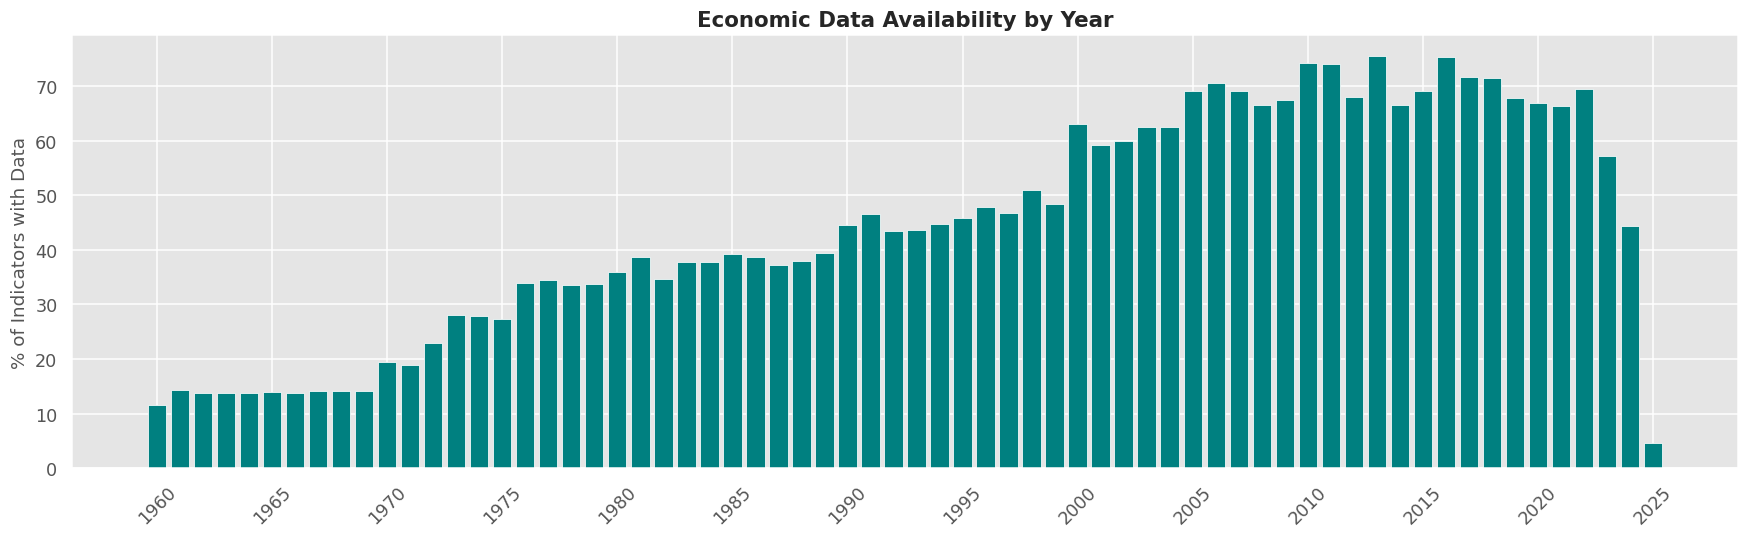

In [297]:
#Data Availability by Year
eco = pd.read_csv('/content/drive/MyDrive/economic_full_1.csv', low_memory=False)
year_cols = [str(y) for y in range(1960, 2026)]
available_pct = [(eco[y].notna().sum() / len(eco) * 100) for y in year_cols]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(year_cols)), available_pct, color='teal', edgecolor='white', width=0.8)
ax.set_xticks(range(0, len(year_cols), 5))
ax.set_xticklabels([year_cols[i] for i in range(0, len(year_cols), 5)], rotation=45)
ax.set_ylabel('% of Indicators with Data')
ax.set_title('Economic Data Availability by Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight — Data Availability
- **2024** still has decent coverage (~30%) but **2025 is nearly empty** (~4.5%). For the PGCB test period (2024–2025), key indicators will need forward-filling.

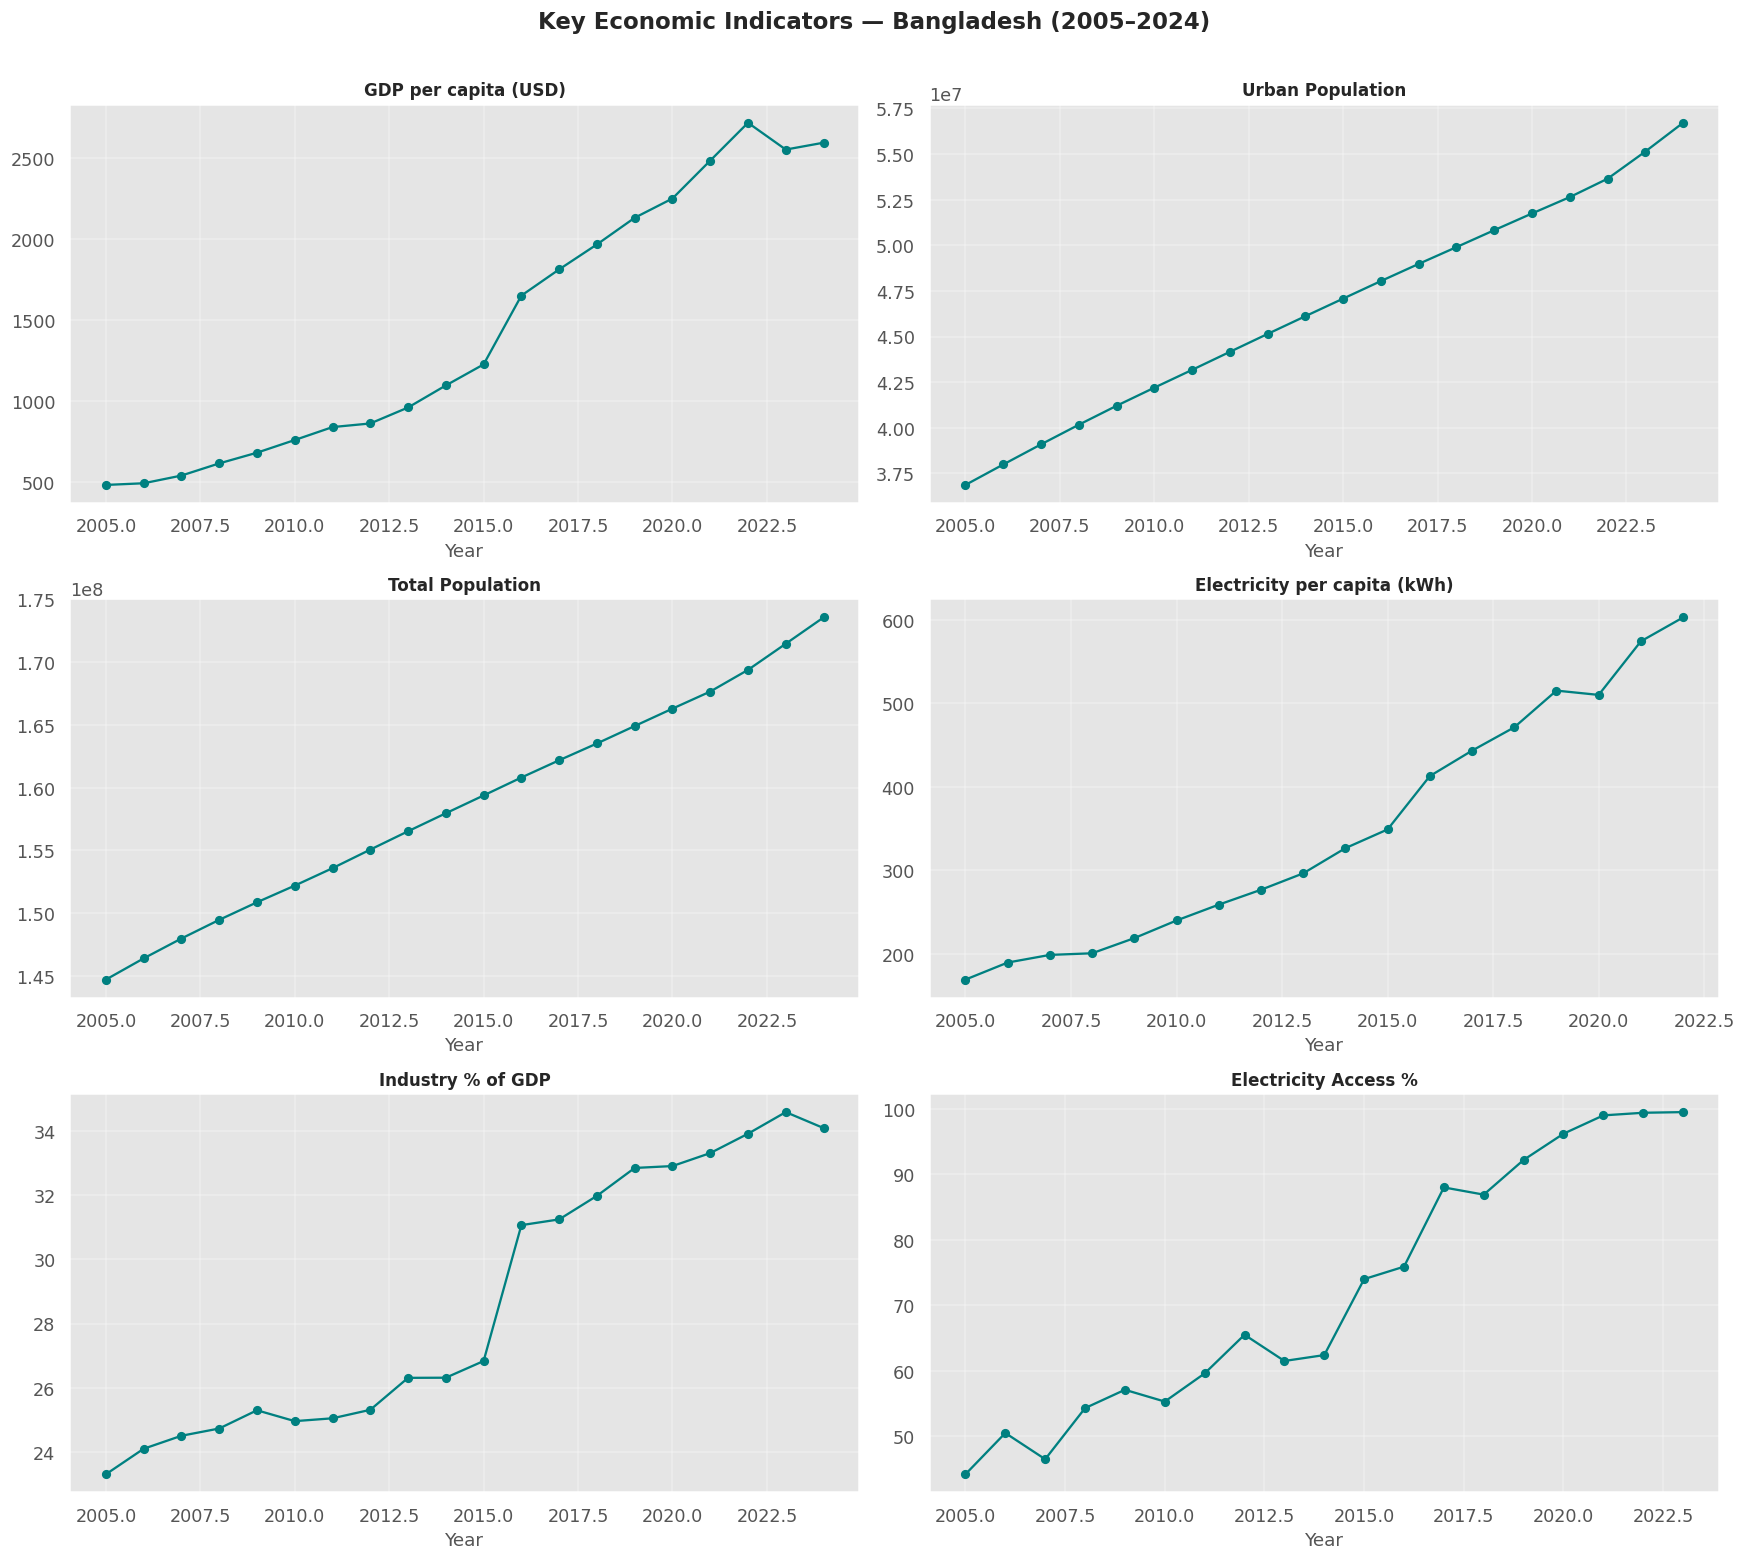

In [298]:
#Key Energy-Relevant Indicators Over Time
key_names = {
    'GDP per capita (current US$)': 'GDP per capita (USD)',
    'Urban population': 'Urban Population',
    'Population, total': 'Total Population',
    'Electric power consumption (kWh per capita)': 'Electricity per capita (kWh)',
    'Industry (including construction), value added (% of GDP)': 'Industry % of GDP',
    'Access to electricity (% of population)': 'Electricity Access %',
}

years = list(range(2005, 2025))
year_strs = [str(y) for y in years]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (ind_name, label) in enumerate(key_names.items()):
    row = eco[eco['Indicator Name'] == ind_name]
    if row.empty:
        axes[i].text(0.5, 0.5, f'{label}\nNot Found', ha='center', va='center', transform=axes[i].transAxes)
        continue
    vals = [row[y].values[0] if y in row.columns else np.nan for y in year_strs]
    axes[i].plot(years, vals, 'o-', color='teal', markersize=5, linewidth=1.5)
    axes[i].set_title(label, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Year')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Economic Indicators — Bangladesh (2005–2024)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Insight — Economic Trends
- **GDP per capita** has grown steadily from ~$500 (2005) to ~$2,600+ (2023) — more income → more appliances → more demand.
- **Urban population** continues to grow — urbanization drives grid-connected electricity consumption.
- **Electricity access** has risen from ~45% to nearly 100% — more people on the grid = more demand.
- **Industry's share of GDP** is rising — industrial processes are electricity-intensive.
- These trends explain the **long-term demand growth** visible in the PGCB data but they change slowly (annually) so they are **near-useless for hourly prediction**. They might help the model understand cross-year demand level differences.

---
# Summary of EDA Findings


In [299]:
#| 1 | PGCB | 432 conflicting duplicate timestamps |
#| 2 | PGCB | 1,055+ completely missing hours (concentrated in 2017) |
#| 3 | PGCB | demand_mw extreme outliers — ×10 entry errors (max 156,050 MW) |
#| 4 | PGCB | generation_mw spike at 64.5M MW; `load_shedding` max 65,359 MW |
#| 5 | PGCB | demand_mw = grid delivery, not true consumer demand |
#| 6 | PGCB | solar/wind/interconnect nulls (infrastructure didn't exist) |
#| 7 | PGCB | remarks column unreliable with mislabeled peaks |
#| 8 | PGCB | 30min readings mixed with hourly data |
#| 10 | Economic | Key energy indicators missing for 2023–2025 (needs forward-fill) |


# **DATA** **CLEANING**

In [300]:
warnings.filterwarnings('ignore')

In [301]:
#Loader & PGCB Cleaning

# Load Data
pgcb = pd.read_csv('/content/drive/MyDrive/PGCB_date_power_demand.csv', low_memory=False)
pgcb['datetime'] = pd.to_datetime(pgcb['datetime'], errors='coerce')

# Sort chronologically before any time-series operations
pgcb = pgcb.sort_values('datetime').reset_index(drop=True)
print(f"Original PGCB rows: {len(pgcb):,}")

# --- Step 1: Demand Outliers ---
# Correct x10 errors where demand is roughly > 8x generation
x10_mask = pgcb['demand_mw'] > (pgcb['generation_mw'] * 8)
pgcb.loc[x10_mask, 'demand_mw'] = pgcb.loc[x10_mask, 'demand_mw'] / 10

# Treat unrealistically low demand (< 30% of generation) as missing
low_mask = pgcb['demand_mw'] < (pgcb['generation_mw'] * 0.3)
pgcb.loc[low_mask, 'demand_mw'] = np.nan

# We will wait to interpolate until after resampling (Step 6) to ensure perfectly continuous hourly indexing.
# But for now, we drop the remarks column since it's text and we need mean aggregation
if 'remarks' in pgcb.columns:
    pgcb = pgcb.drop(columns=['remarks'])

# --- Step 2: Load Shedding Recalculation ---
# Recalculate load shedding where x10 errors occurred
pgcb.loc[x10_mask, 'load_shedding'] = np.maximum(0, pgcb.loc[x10_mask, 'demand_mw'] - pgcb.loc[x10_mask, 'generation_mw'])
# Ensure it's never negative and never greater than demand everywhere
pgcb['load_shedding'] = np.clip(pgcb['load_shedding'], 0, pgcb['demand_mw'])

# --- Step 3: Missing Values in Generation Sources ---
fill_zero_cols = ['solar', 'wind', 'nepal', 'india_adani']
for col in fill_zero_cols:
    if col in pgcb.columns:
        pgcb[col] = pgcb[col].fillna(0)

# --- Step 4: Duplicate Timestamps ---
# Group by datetime and take mean
pgcb = pgcb.groupby('datetime', as_index=False).mean()

# --- Step 5: Resample to Hourly Frequency ---
pgcb.set_index('datetime', inplace=True)
pgcb = pgcb.resample('1h').mean()

# --- Step 6: Complete Hourly Timeline & Interpolation ---
# The .resample('1h') inherently creates the complete timeline and inserts NaNs.
# Now we use time-based interpolation to fill NaNs.
pgcb = pgcb.interpolate(method='time')
pgcb = pgcb.reset_index()

print(f"Cleaned PGCB rows (Hourly): {len(pgcb):,}")

Original PGCB rows: 92,650
Cleaned PGCB rows (Hourly): 89,101


In [302]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [303]:
#Weather & Economic Data Cleaning

#Weather Data Cleaning
weather = pd.read_csv('/content/drive/MyDrive/weather_data.csv', skiprows=3, low_memory=False, encoding='latin1')
# Standardize columns based on known format
weather.columns = ['datetime','temp_c','humidity_pct','apparent_temp_c','precip_mm',
                   'dewpoint_c','soil_temp_c','wind_dir_deg','cloud_pct','sunshine_sec']

weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')

# Ensure numeric types
for col in weather.columns:
    if col != 'datetime':
        weather[col] = pd.to_numeric(weather[col], errors='coerce')

weather = weather.dropna(subset=['datetime']).sort_values('datetime')
# Drop duplicates just in case
weather = weather.drop_duplicates('datetime')
print(f"Weather rows: {len(weather):,}")

#Economic Data cleaning
eco = pd.read_csv('/content/drive/MyDrive/economic_full_1.csv', low_memory=False)

target_keywords = [
    'GDP (current US$)',
    'GDP growth (annual %)',
    'GDP per capita (current US$)',
    'GDP per capita growth (annual %)',
    'Gross capital formation (% of GDP)',
    'Industry (including construction), value added (% of GDP)',
    'Manufacturing, value added (% of GDP)',
    'Population, total',
    'Population growth (annual %)',
    'Urban population (% of total population)',
    'Electric power consumption (kWh per capita)',
    'Energy use (kg of oil equivalent per capita)',
    'Electric power transmission and distribution losses (% of output)',
    'Renewable energy consumption (% of total final energy consumption)',
    'Exports of goods and services (% of GDP)',
    'Imports of goods and services (% of GDP)',
    'Trade (% of GDP)',
    'Inflation, consumer prices (annual %)',
    'Consumer price index (2010 = 100)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Access to electricity (% of population)',
    'Fixed broadband subscriptions',
    'Mobile cellular subscriptions'
]

# Match indicators
eco_subset = eco[eco['Indicator Name'].isin(target_keywords)]

# Convert wide to long
year_cols = [str(y) for y in range(1960, 2026) if str(y) in eco.columns]
melted = eco_subset.melt(id_vars=['Indicator Name'], value_vars=year_cols, var_name='year', value_name='value')
melted['year'] = melted['year'].astype(int)
melted['value'] = pd.to_numeric(melted['value'], errors='coerce')

# Pivot long back to wide so each indicator is a column
eco_pivoted = melted.pivot_table(index='year', columns='Indicator Name', values='value').reset_index()
print(f"Economic data ready, shape: {eco_pivoted.shape}")
eco_pivoted.head()

Weather rows: 107,304
Economic data ready, shape: (66, 24)


Indicator Name,year,Access to electricity (% of population),Consumer price index (2010 = 100),Electric power consumption (kWh per capita),Electric power transmission and distribution losses (% of output),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),Fixed broadband subscriptions,GDP (current US$),GDP growth (annual %),...,"Industry (including construction), value added (% of GDP)","Inflation, consumer prices (annual %)","Manufacturing, value added (% of GDP)",Mobile cellular subscriptions,Population growth (annual %),"Population, total",Renewable energy consumption (% of total final energy consumption),Trade (% of GDP),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,1960,NaN,NaN,NaN,NaN,NaN,9.996685,NaN,4.274894e+09,NaN,...,6.973816,NaN,5.309911,0.0,NaN,51828660.0,NaN,19.303944,NaN,5.112178
1,1961,NaN,NaN,NaN,NaN,NaN,10.782353,NaN,4.817580e+09,6.058161,...,6.794118,NaN,5.470589,NaN,2.818718,53310348.0,NaN,22.482352,NaN,5.277111
2,1962,NaN,NaN,NaN,NaN,NaN,10.746751,NaN,5.081414e+09,5.453031,...,7.963862,NaN,5.448665,NaN,2.903941,54881146.0,NaN,21.554848,NaN,5.465581
3,1963,NaN,NaN,NaN,NaN,NaN,9.983485,NaN,5.319459e+09,-0.455894,...,7.804593,NaN,5.359331,NaN,2.914868,56504402.0,NaN,21.639763,NaN,5.656050
4,1964,NaN,NaN,NaN,NaN,NaN,10.028412,NaN,5.386055e+09,10.952789,...,10.423024,NaN,5.514049,NaN,2.919516,58178374.0,NaN,24.150268,NaN,5.854935


In [304]:
# Merge and Train/Test Split

# Merge Datasets
# Merge Weather onto PGCB
master = pd.merge(pgcb, weather, on='datetime', how='left')

# Set datetime as index
master = master.set_index('datetime')
master = master.interpolate(method='time')
master = master.reset_index()
master['year'] = master['datetime'].dt.year
master = pd.merge(master, eco_pivoted, on='year', how='left')

economic_cols = [col for col in eco_pivoted.columns if col != 'year']

master = master.sort_values('datetime')
for col in economic_cols:
    master[col] = master[col].ffill()

master = master.sort_values('datetime').reset_index(drop=True)

#Train/Test Split
# Discard any records beyond 2024.
master = master[master['datetime'].dt.year <= 2024]

# Train: 2015-04-19 to 2023-12-31
train_mask = (master['datetime'] >= '2015-04-19') & (master['datetime'] <= '2023-12-31')
train_df = master[train_mask].copy()

# Test: 2024-01-01 to 2024-12-31
test_mask = (master['datetime'] >= '2024-01-01') & (master['datetime'] <= '2024-12-31')
test_df = master[test_mask].copy()

print(f"Final Master Shape: {master.shape}")
print(f"Train Shape (2015-2023): {train_df.shape}")
print(f"Test Shape (2024): {test_df.shape}")

Final Master Shape: (85080, 47)
Train Shape (2015-2023): (76273, 47)
Test Shape (2024): (8761, 47)


In [305]:
# Save the cleaned datasets
train_df.to_csv('train_data_clean.csv', index=False)
test_df.to_csv('test_data_clean.csv', index=False)
print("Data saved successfully to 'train_data_clean.csv' and 'test_data_clean.csv'!")

Data saved successfully to 'train_data_clean.csv' and 'test_data_clean.csv'!


# Feature Engineering

In [306]:
#Load Data
train_df = pd.read_csv('train_data_clean.csv', low_memory=False)
test_df = pd.read_csv('test_data_clean.csv', low_memory=False)

# Recombine temporarily purely to preserve chronological context for rolling/lags into 2024 boundary
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f"Combined data shape for feature engineering: {df.shape}")

Combined data shape for feature engineering: (85034, 47)


In [307]:
#Time Features

# Cyclical time logic
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month

# Bangladesh weekend is Friday(4) Saturday(5)
df['is_weekend'] = df['day_of_week'].isin([4, 5]).astype(int)

# Season definition mapping
def get_season(month):
    if month in [12, 1, 2]: return 1
    elif month in [3, 4, 5]: return 2
    elif month in [6, 7, 8, 9]: return 3
    else: return 4
df['season'] = df['month'].apply(get_season)
df[['datetime', 'hour', 'day_of_week', 'is_weekend', 'season']].head()

,datetime,hour,day_of_week,is_weekend,season
0,2015-04-19 00:00:00,0,6,0,2
1,2015-04-19 01:00:00,1,6,0,2
2,2015-04-19 02:00:00,2,6,0,2
3,2015-04-19 03:00:00,3,6,0,2
4,2015-04-19 04:00:00,4,6,0,2


In [308]:
#Lag featues

orig_cols = list(df.columns)

lag_hours = [1, 3, 24, 48, 168]
for h in lag_hours:
    df[f'demand_mw_lag_{h}'] = df['demand_mw'].shift(h)
    df[f'generation_mw_lag_{h}'] = df['generation_mw'].shift(h)
print("Demand & Generation Lags Engineered.")

Demand & Generation Lags Engineered.


In [309]:
#Rolling statistics features

for h in [24, 168]:
    df[f'demand_rolling_mean_{h}'] = df['demand_mw'].shift(1).rolling(window=h, min_periods=1).mean()
    df[f'demand_rolling_std_{h}'] = df['demand_mw'].shift(1).rolling(window=h, min_periods=1).std()

df[['datetime', 'demand_mw', 'demand_rolling_mean_24']].head()

,datetime,demand_mw,demand_rolling_mean_24
0,2015-04-19 00:00:00,4821.0,NaN
1,2015-04-19 01:00:00,3612.0,4821.000000
2,2015-04-19 02:00:00,3727.0,4216.500000
3,2015-04-19 03:00:00,3632.0,4053.333333
4,2015-04-19 04:00:00,3641.0,3948.000000


In [310]:
df = df.sort_values('datetime').reset_index(drop=True)

# 1. Temporal features

df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Cyclical encoding helps tree models understand that 23:00 is next to 00:00
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 2. Weather features

# Demand spikes non-linearly with extreme heat
df['temp_c_squared'] = df['temp_c'] ** 2

# Cooling Degree Hours (CDH) - Captures Air Conditioning spikes
# Assuming 24°C is the comfort baseline in Bangladesh
df['CDH'] = df['temp_c'].apply(lambda x: max(0, x - 24))

# Weather-Time Interaction (Heat impacts demand more during peak hours)
df['temp_x_hour'] = df['temp_c'] * df['hour']



# 3. Lag features
# These predict the next hour based on exact past behaviors
df['demand_mw_lag_1'] = df['demand_mw'].shift(1)     # Previous hour
df['demand_mw_lag_24'] = df['demand_mw'].shift(24)   # Same hour yesterday
df['demand_mw_lag_168'] = df['demand_mw'].shift(168) # Same hour last week



# 4. rolling statistics features

# Shift(1) is CRITICAL here to prevent data leakage from the current hour
df['demand_rolling_mean_24'] = df['demand_mw'].shift(1).rolling(window=24).mean()
df['demand_rolling_std_24'] = df['demand_mw'].shift(1).rolling(window=24).std()
df['temp_rolling_mean_24'] = df['temp_c'].shift(1).rolling(window=24).mean()



# 5. Noise Reduction (Drop useless columns)
# Drop macro-economic data that stays constant for 8760 hours and adds noise
# Also drop highly correlated target leaks like 'generation_mw'
cols_to_drop = [
    'generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal',
    'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura',
    'india_adani', 'nepal', 'year', 'GDP (current US$)', 'GDP growth (annual %)',
    'GDP per capita (current US$)', 'GDP per capita growth (annual %)',
    'Population growth (annual %)', 'Population, total', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Consumer price index (2010 = 100)',
    'Electric power consumption (kWh per capita)', 'Electric power transmission and distribution losses (% of output)',
    'Energy use (kg of oil equivalent per capita)', 'Exports of goods and services (% of GDP)',
    'Fixed broadband subscriptions', 'Gross capital formation (% of GDP)',
    'Imports of goods and services (% of GDP)', 'Industry (including construction), value added (% of GDP)',
    'Manufacturing, value added (% of GDP)', 'Mobile cellular subscriptions',
    'Renewable energy consumption (% of total final energy consumption)', 'Trade (% of GDP)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Urban population (% of total population)'
]

# Drop if they exist in the dataframe
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Drop NaN values created by the 168-hour lag
df = df.dropna().reset_index(drop=True)

print(f"Engineered successfully. Final feature width: {df.shape[1]}")

Engineered successfully. Final feature width: 38


In [311]:
#weather features

weather_cols = ['temp_c', 'humidity_pct', 'wind_dir_deg', 'precip_mm']
for col in weather_cols:
    if col in df.columns:
        df[f'{col}_lag_1'] = df[col].shift(1)
        df[f'{col}_lag_3'] = df[col].shift(3)
        df[f'{col}_rolling_mean_24'] = df[col].shift(1).rolling(window=24, min_periods=1).mean()

# Interaction features targeting HVAC load
if 'temp_c' in df.columns and 'humidity_pct' in df.columns:
    df['temp_x_humidity'] = df['temp_c'] * df['humidity_pct']             # Heat Stress Proxy
    df['cooling_degree'] = np.maximum(df['temp_c'] - 24.0, 0.0)           # Base 24C Max
    df['heating_degree'] = np.maximum(18.0 - df['temp_c'], 0.0)           # Base 18C Min

df[['datetime'] + [c for c in ['temp_c', 'humidity_pct', 'temp_x_humidity', 'cooling_degree'] if c in df.columns]].head()

,datetime,temp_c,humidity_pct,temp_x_humidity,cooling_degree
0,2015-04-26 00:00:00,22.0,91,2002.0,0.0
1,2015-04-26 01:00:00,21.8,93,2027.4,0.0
2,2015-04-26 02:00:00,21.6,94,2030.4,0.0
3,2015-04-26 03:00:00,21.4,94,2011.6,0.0
4,2015-04-26 04:00:00,21.5,94,2021.0,0.0


In [312]:
# final test train split file

# Train Test Splits
train_df = df[(df['datetime'] >= '2015-04-19') & (df['datetime'] <= '2023-12-31')]
test_df = df[(df['datetime'] >= '2024-01-01') & (df['datetime'] <= '2024-12-31')]

# Save
df.to_csv('feature_engineering.csv', index=False)
train_df.to_csv('train_features.csv', index=False)
test_df.to_csv('test_features.csv', index=False)

print(f"Engineered successfully. Final feature width: {len(df.columns)}")
print(f"Train subset: {len(train_df)}")
print(f"Test subset: {len(test_df)}")

Engineered successfully. Final feature width: 53
Train subset: 76105
Test subset: 8761


## Model Training

In [313]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('ggplot')

# 1. Load the data
train_df = pd.read_csv('train_features.csv', parse_dates=['datetime'])
test_df = pd.read_csv('test_features.csv', parse_dates=['datetime'])

train_df.set_index('datetime', inplace=True)
test_df.set_index('datetime', inplace=True)

# 2. DEFINE THE LEAKY COLUMNS TO DROP
target = 'demand_mw'
leaky_columns = [
    'generation_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal',
    'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura',
    'india_adani', 'nepal'
]

# Ensure we drop them if they exist in the dataframe
cols_to_drop = [col for col in leaky_columns if col in train_df.columns]

# 3. Define Features and Target safely
X_train = train_df.drop(columns=[target] + cols_to_drop)
y_train = train_df[target]

X_test = test_df.drop(columns=[target] + cols_to_drop)
y_test = test_df[target]

print(f"Cleaned training features: {X_train.shape[1]}")
print(f"Training samples: {len(X_train)}")

Cleaned training features: 51
Training samples: 76105


In [314]:
# 1. Create a validation set from the end of the training data (Time-Series safe)
split_idx = int(len(X_train) * 0.9)
X_tr, y_tr = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

# 2. Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=1000,          # Maximum number of trees
    learning_rate=0.05,         # Slower learning rate for better generalization
    max_depth=6,                # Depth of trees
    subsample=0.8,              # Use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,       # Use 80% of features per tree
    objective='reg:squarederror',
    early_stopping_rounds=50,   # Stop if validation score doesn't improve for 50 rounds
    random_state=42
)

# 3. Train the model
print("Training XGBoost Model...")
model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=100  # Print progress every 100 trees
)
print("Training Complete!")

Training XGBoost Model...
[0]	validation_0-rmse:2050.28889	validation_1-rmse:3723.06215
[100]	validation_0-rmse:221.03868	validation_1-rmse:414.74344
[200]	validation_0-rmse:190.17919	validation_1-rmse:393.57161
[300]	validation_0-rmse:176.62866	validation_1-rmse:388.11042
[372]	validation_0-rmse:169.42906	validation_1-rmse:387.84890
Training Complete!


In [315]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Generate Predictions on the unseen 2024 Test Set
preds = model.predict(X_test)

# 2. Custom MAPE Function
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
mape = calculate_mape(y_test.values, preds)

print("=== FINAL MODEL EVALUATION ===")
print(f"RMSE:  {rmse:.2f} MW")
print(f"MAE:   {mae:.2f} MW")
print(f"R²:    {r2:.4f}")
print(f"MAPE:  {mape:.2f}%")

=== FINAL MODEL EVALUATION ===
RMSE:  517.40 MW
MAE:   318.49 MW
R²:    0.9553
MAPE:  2.68%


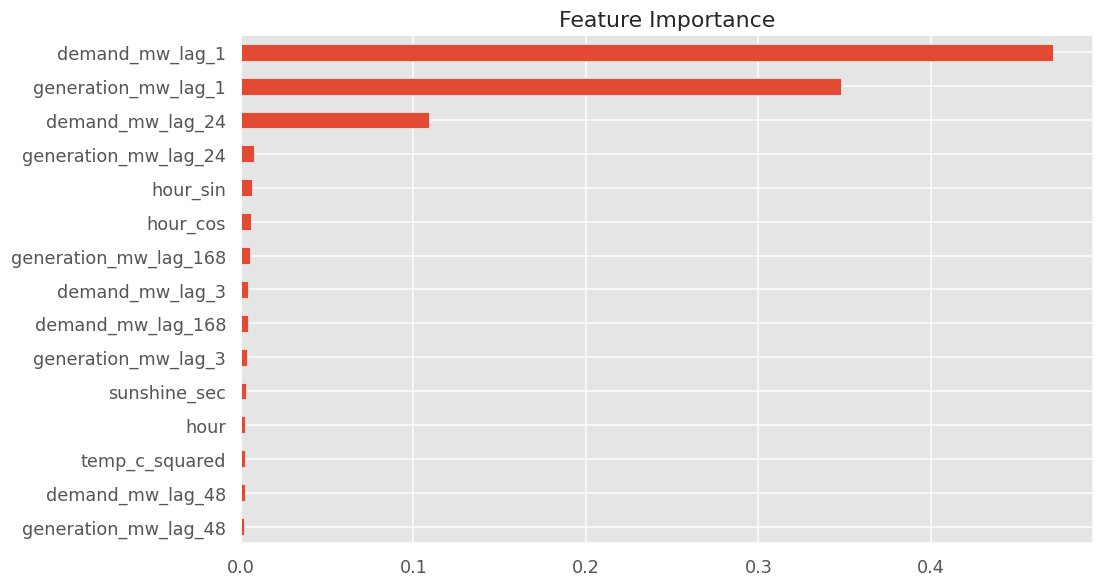

In [316]:
# check which features are actually driving the predictions
importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

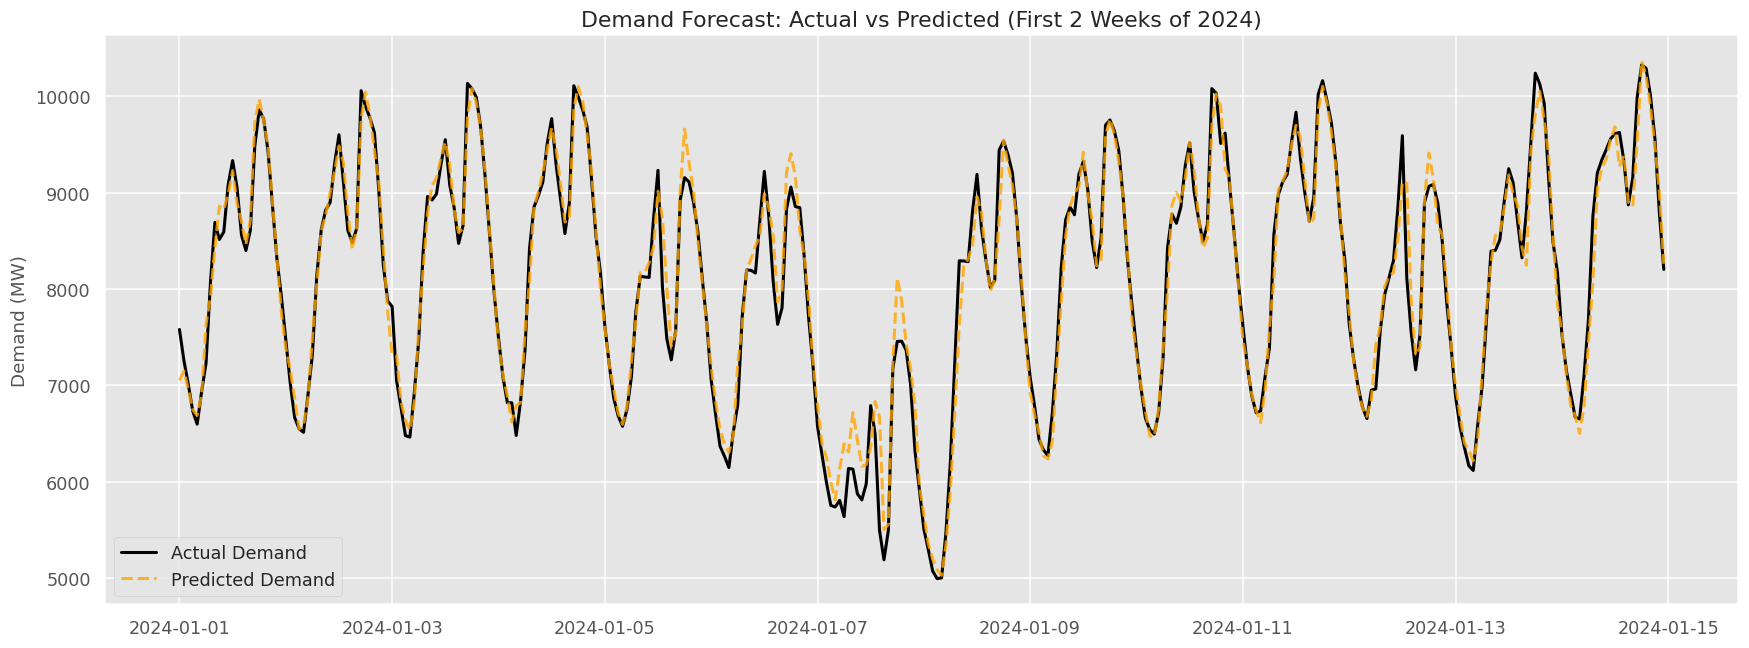

In [317]:
# Plot Actual vs Predicted for the first 2 weeks (336 hours) of 2024
plt.figure(figsize=(16, 6))
plt.plot(y_test.index[:336], y_test.values[:336], label='Actual Demand', color='black', linewidth=2)
plt.plot(y_test.index[:336], preds[:336], label='Predicted Demand', color='orange', alpha=0.8, linewidth=2, linestyle='--')
plt.title('Demand Forecast: Actual vs Predicted (First 2 Weeks of 2024)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()